In [2]:
!pip install xgboost --quiet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
COLORS = {'gol': '#e63946', 'no_gol': '#457b9d', 'neutral': '#2E4057'}

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


In [4]:
from google.colab import drive
drive.mount('/content/drive')
import pickle

ruta = '/content/drive/MyDrive/TFM_xG/'

X_train = pd.read_csv(ruta + 'X_train.csv')
X_val   = pd.read_csv(ruta + 'X_val.csv')
X_test  = pd.read_csv(ruta + 'X_test.csv')
y_train = pd.read_csv(ruta + 'y_train.csv').squeeze()
y_val   = pd.read_csv(ruta + 'y_val.csv').squeeze()
y_test  = pd.read_csv(ruta + 'y_test.csv').squeeze()

with open(ruta + 'features.pkl', 'rb') as f:
    features = pickle.load(f)

print('Datos cargados correctamente.')
print(f'  Train:      {X_train.shape}')
print(f'  Validacion: {X_val.shape}')
print(f'  Test:       {X_test.shape}')
print(f'  Features:   {len(features)} variables predictoras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datos cargados correctamente.
  Train:      (17079, 14)
  Validacion: (3660, 14)
  Test:       (3660, 14)
  Features:   14 variables predictoras


Se cogen desde Google Drive los seis archivos de datos que ya estaban listos en el Notebook 02 y se comprueba que tienen el tamaño correcto: 17.079 registros para entrenar y 3.660 para validar y probar. Cada uno con 14 datos que ayudan a hacer las predicciones.

In [5]:
print('PLANTEAMIENTO DEL PROBLEMA')
print('=' * 50)
print(f'Tipo de problema:  Clasificacion binaria')
print(f'Variable objetivo: gol (1=gol, 0=no gol)')
print(f'Desbalance:        {y_train.value_counts()[0]:,} no goles vs {y_train.value_counts()[1]:,} goles')
print(f'Ratio:             {y_train.value_counts()[0]/y_train.value_counts()[1]:.1f}:1')
print(f'Metrica principal: AUC-ROC')
print(f'\nVariables predictoras ({len(features)}):')
for f in features:
    print(f'  - {f}')

PLANTEAMIENTO DEL PROBLEMA
Tipo de problema:  Clasificacion binaria
Variable objetivo: gol (1=gol, 0=no gol)
Desbalance:        15,127 no goles vs 1,952 goles
Ratio:             7.7:1
Metrica principal: AUC-ROC

Variables predictoras (14):
  - shot_distance
  - shot_angle
  - under_pressure
  - shot_first_time
  - minute
  - shot_body_part_Left Foot
  - shot_body_part_Other
  - shot_body_part_Right Foot
  - shot_technique_Diving Header
  - shot_technique_Half Volley
  - shot_technique_Lob
  - shot_technique_Normal
  - shot_technique_Overhead Kick
  - shot_technique_Volley


El problema consiste en determinar si un disparo termina en gol o no. La tarea se presenta como una especie de "sí" o "no". En los datos utilizados para aprender, hay muchas más ocasiones en las que no se marca un gol (15.127) en comparación con las que sí se marca (1.952). Esto significa que hay muchas más respuestas negativas que positivas, con una diferencia aproximadamente de 7,7 a 1. Por eso, se usa una medida llamada AUC-ROC para evaluar cómo funciona el sistema, ya que esta medida funciona bien cuando hay muchas más respuestas negativas que positivas.

In [6]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)


y_prob_lr_val = lr.predict_proba(X_val)[:, 1]
auc_lr_val = roc_auc_score(y_val, y_prob_lr_val)


cv_lr = cross_val_score(lr, X_train, y_train, cv=5, scoring='roc_auc')

print('REGRESION LOGISTICA (Baseline)')
print('=' * 40)
print(f'AUC-ROC Validacion:      {auc_lr_val:.4f}')
print(f'AUC-ROC CV (5-fold):     {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}')
print(f'\nCoeficientes del modelo:')
coef_df = pd.DataFrame({
    'variable': features,
    'coeficiente': lr.coef_[0],
    'odds_ratio': np.exp(lr.coef_[0])
}).sort_values('coeficiente', ascending=False)
print(coef_df.to_string(index=False))

REGRESION LOGISTICA (Baseline)
AUC-ROC Validacion:      0.8032
AUC-ROC CV (5-fold):     0.7827 +/- 0.0183

Coeficientes del modelo:
                    variable  coeficiente  odds_ratio
          shot_technique_Lob     1.930107    6.890249
    shot_body_part_Left Foot     1.550147    4.712162
   shot_body_part_Right Foot     1.522645    4.584334
shot_technique_Diving Header     1.267313    3.551299
       shot_technique_Normal     0.968158    2.633091
       shot_technique_Volley     0.262037    1.299574
  shot_technique_Half Volley     0.198257    1.219275
             shot_first_time     0.068260    1.070644
                  shot_angle     0.030047    1.030503
                      minute     0.000510    1.000510
               shot_distance    -0.105938    0.899480
        shot_body_part_Other    -0.166301    0.846791
              under_pressure    -0.306935    0.735699
shot_technique_Overhead Kick    -0.316853    0.728438


La regresión logística logró un buen rendimiento, con 0.8032 en la prueba de validación y 0.7827 en validación cruzada. Ésta ayuda a verificar que los resultados sean confiables. Los análisis indican que los factores más importantes para predecir un gol son la técnica de disparo (especialmente cuando se usa el lob), y la parte del cuerpo que se usa para tirar (pie izquierdo y pie derecho). Por otro lado, disparar cuando la persona está bajo presión disminuye mucho las posibilidades de marcar un gol.

In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_prob_rf_val = rf.predict_proba(X_val)[:, 1]
auc_rf_val = roc_auc_score(y_val, y_prob_rf_val)

cv_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')

print('RANDOM FOREST')
print('=' * 40)
print(f'AUC-ROC Validacion:  {auc_rf_val:.4f}')
print(f'AUC-ROC CV (5-fold): {cv_rf.mean():.4f} +/- {cv_rf.std():.4f}')

RANDOM FOREST
AUC-ROC Validacion:  0.8016
AUC-ROC CV (5-fold): 0.7794 +/- 0.0191


El modelo Random Forest consigue una puntuación de 0.8016 en la validación y 0.7794 en las pruebas cruzadas. Esto es un poco menos que la regresión logística. Como es un conjunto de árboles de decisión que trabaja en grupo, puede detectar relaciones complejas entre las variables. Pero en este caso no logra mejorar los resultados base.

In [8]:
ratio_desbalance = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio_desbalance,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)
xgb.fit(X_train, y_train)

y_prob_xgb_val = xgb.predict_proba(X_val)[:, 1]
auc_xgb_val = roc_auc_score(y_val, y_prob_xgb_val)

cv_xgb = cross_val_score(xgb, X_train, y_train, cv=5, scoring='roc_auc')

print('XGBOOST')
print('=' * 40)
print(f'AUC-ROC Validacion:  {auc_xgb_val:.4f}')
print(f'AUC-ROC CV (5-fold): {cv_xgb.mean():.4f} +/- {cv_xgb.std():.4f}')

XGBOOST
AUC-ROC Validacion:  0.7984
AUC-ROC CV (5-fold): 0.7706 +/- 0.0174


XGBoost logra un puntaje de aproximadamente 0.7984 en la prueba de validación y de 0.7706 en una validación cruzada. Aunque suele ser uno de los mejores modelos para datos en forma de tablas, en este caso no supera a la regresión logística. Esto indica que la relación entre las variables que usamos para predecir y la probabilidad de que se marque un gol es principalmente lineal. Es decir, que sigue una línea recta.

In [9]:
resultados = pd.DataFrame({
    'Modelo': ['Regresion Logistica', 'Random Forest', 'XGBoost'],
    'AUC-ROC Validacion': [auc_lr_val, auc_rf_val, auc_xgb_val],
    'AUC-ROC CV Media': [cv_lr.mean(), cv_rf.mean(), cv_xgb.mean()],
    'AUC-ROC CV Std': [cv_lr.std(), cv_rf.std(), cv_xgb.std()]
}).round(4)

print('COMPARACION DE MODELOS')
print('=' * 60)
print(resultados.to_string(index=False))
print(f'\nMejor modelo por AUC-ROC en validacion: '
      f'{resultados.loc[resultados["AUC-ROC Validacion"].idxmax(), "Modelo"]}')

COMPARACION DE MODELOS
             Modelo  AUC-ROC Validacion  AUC-ROC CV Media  AUC-ROC CV Std
Regresion Logistica              0.8032            0.7827          0.0183
      Random Forest              0.8016            0.7794          0.0191
            XGBoost              0.7984            0.7706          0.0174

Mejor modelo por AUC-ROC en validacion: Regresion Logistica


Los tres modelos que se prueban dan resultados parecidos, con AUC-ROC que varía entre 0.79 y 0.80. La regresión logística es el modelo que funciona mejor, con un valor de 0.8032 en la prueba, seguido muy de cerca por Random Forest con 0.8016 y XGBoost con 0.7984. Estos números están en línea con lo que suelen mostrar otros estudios sobre modelos similares, donde un AUC entre 0.75 y 0.85 se considera una buena y confiable opción.

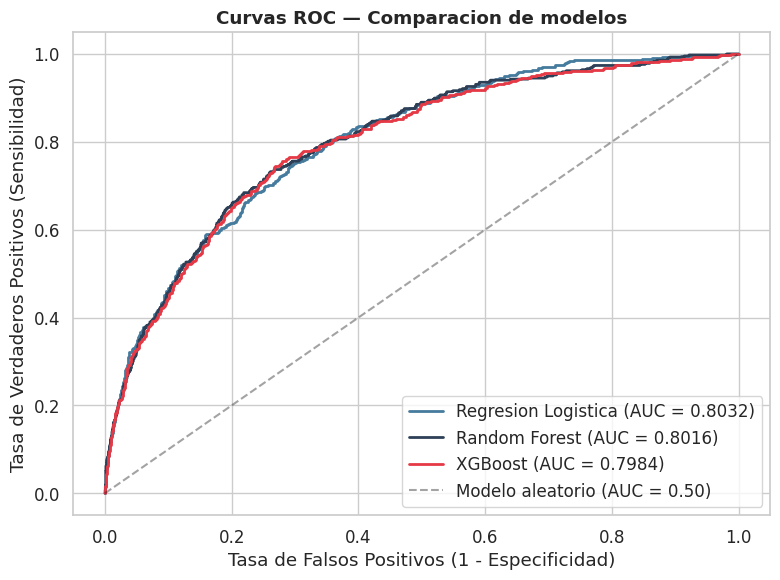

Grafico guardado como curvas_roc.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

modelos = [
    ('Regresion Logistica', y_prob_lr_val, auc_lr_val, COLORS['no_gol']),
    ('Random Forest',       y_prob_rf_val, auc_rf_val, COLORS['neutral']),
    ('XGBoost',             y_prob_xgb_val, auc_xgb_val, COLORS['gol'])
]

for nombre, y_prob, auc, color in modelos:
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{nombre} (AUC = {auc:.4f})')

ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Modelo aleatorio (AUC = 0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax.set_title('Curvas ROC — Comparacion de modelos', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado como curvas_roc.png')

Las gráficas de las curvas ROC muestran claramente que los tres modelos son muy parecidos en su capacidad para distinguir entre las diferentes situaciones. Todos funcionan mucho mejor que simplemente hacer una elección aleatoria (que tendría un valor de 0.50). Además, las curvas casi se sobreponen, lo que indica que no hay diferencias importantes entre ellos y que usar la regresión logística es suficiente para resolver este problema.

In [11]:
mejor_idx = resultados['AUC-ROC Validacion'].idxmax()
mejor_nombre = resultados.loc[mejor_idx, 'Modelo']

modelos_dict = {
    'Regresion Logistica': (lr, y_prob_lr_val),
    'Random Forest': (rf, y_prob_rf_val),
    'XGBoost': (xgb, y_prob_xgb_val)
}
mejor_modelo = modelos_dict[mejor_nombre][0]

y_prob_test = mejor_modelo.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_prob_test)

threshold = y_train.mean()
y_pred_test = (y_prob_test >= threshold).astype(int)

print(f'EVALUACION FINAL EN TEST — {mejor_nombre}')
print('=' * 50)
print(f'AUC-ROC en test: {auc_test:.4f}')
print(f'Punto de corte usado: {threshold:.4f}')
print(f'\nReporte de clasificacion:')
print(classification_report(y_test, y_pred_test,
                             target_names=['No gol', 'Gol']))

EVALUACION FINAL EN TEST — Regresion Logistica
AUC-ROC en test: 0.7712
Punto de corte usado: 0.1143

Reporte de clasificacion:
              precision    recall  f1-score   support

      No gol       0.95      0.72      0.82      3242
         Gol       0.24      0.69      0.36       418

    accuracy                           0.72      3660
   macro avg       0.60      0.71      0.59      3660
weighted avg       0.87      0.72      0.77      3660



La regresión logística se prueba con datos que no se usaron para entrenarla. En esta prueba, obtiene un resultado AUC-ROC de 0.7712. Se usó un punto de corte de 0.1143 (que es parecido a la proporción de goles en los datos de entrenamiento). El modelo logra identificar correctamente el 69% de los goles (recall), pero solo acierta como goles el 24% de las veces cuando dice que hay gol. Esto es normal porque hay muchas más ocasiones sin goles que con goles.

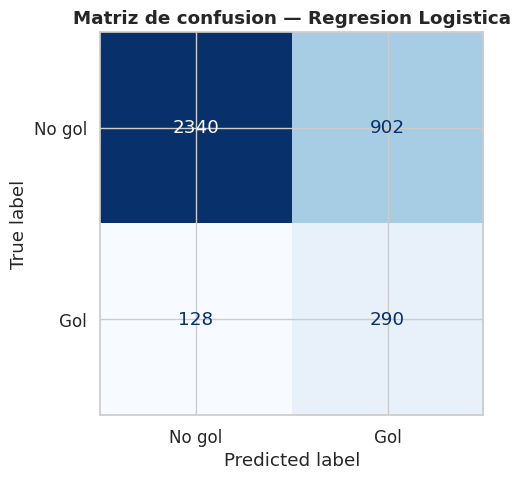

Grafico guardado como matriz_confusion.png


In [12]:
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No gol', 'Gol'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de confusion — {mejor_nombre}', fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafico guardado como matriz_confusion.png')

La matriz de confusión nos indica que el modelo identifica correctamente 2.340 veces que no hay gol y 290 veces que sí hay gol. Sin embargo, también comete errores: 902 veces dice que hay gol cuando en realidad no lo hay (falsos positivos) y 128 veces que no detecta un gol cuando en realidad sí hubo (falsos negativos). Es importante señalar que el número de falsos negativos es relativamente bajo. Esto es importante para el negocio ya que esto significa que el modelo tiende a ser cauteloso y evita perder muchos goles reales en sus predicciones.

In [13]:
with open('mejor_modelo.pkl', 'wb') as f:
    pickle.dump(mejor_modelo, f)

with open('mejor_modelo_nombre.pkl', 'wb') as f:
    pickle.dump(mejor_nombre, f)

print(f'Modelo guardado: {mejor_nombre}')
print('Listo para el notebook 04_interpretabilidad.ipynb')

Modelo guardado: Regresion Logistica
Listo para el notebook 04_interpretabilidad.ipynb


El mejor modelo (Regresión Logística) se guarda en un archivo pickle.

In [14]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/TFM_xG/'

# Guardar el mejor modelo en Google Drive
with open(ruta + 'mejor_modelo.pkl', 'wb') as f:
    pickle.dump(mejor_modelo, f)

with open(ruta + 'mejor_modelo_nombre.pkl', 'wb') as f:
    pickle.dump(mejor_nombre, f)

print(f'Modelo guardado en Drive: {mejor_nombre}')
print('Listo para el notebook 04_interpretabilidad.ipynb')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo guardado en Drive: Regresion Logistica
Listo para el notebook 04_interpretabilidad.ipynb
